In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 16, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

,value_0
timestamp,
2025-08-03 00:00:00,1414.2
2025-08-03 00:05:00,1369.1
2025-08-03 00:10:00,1381.5
2025-08-03 00:15:00,1387.1
2025-08-03 00:20:00,1298.7


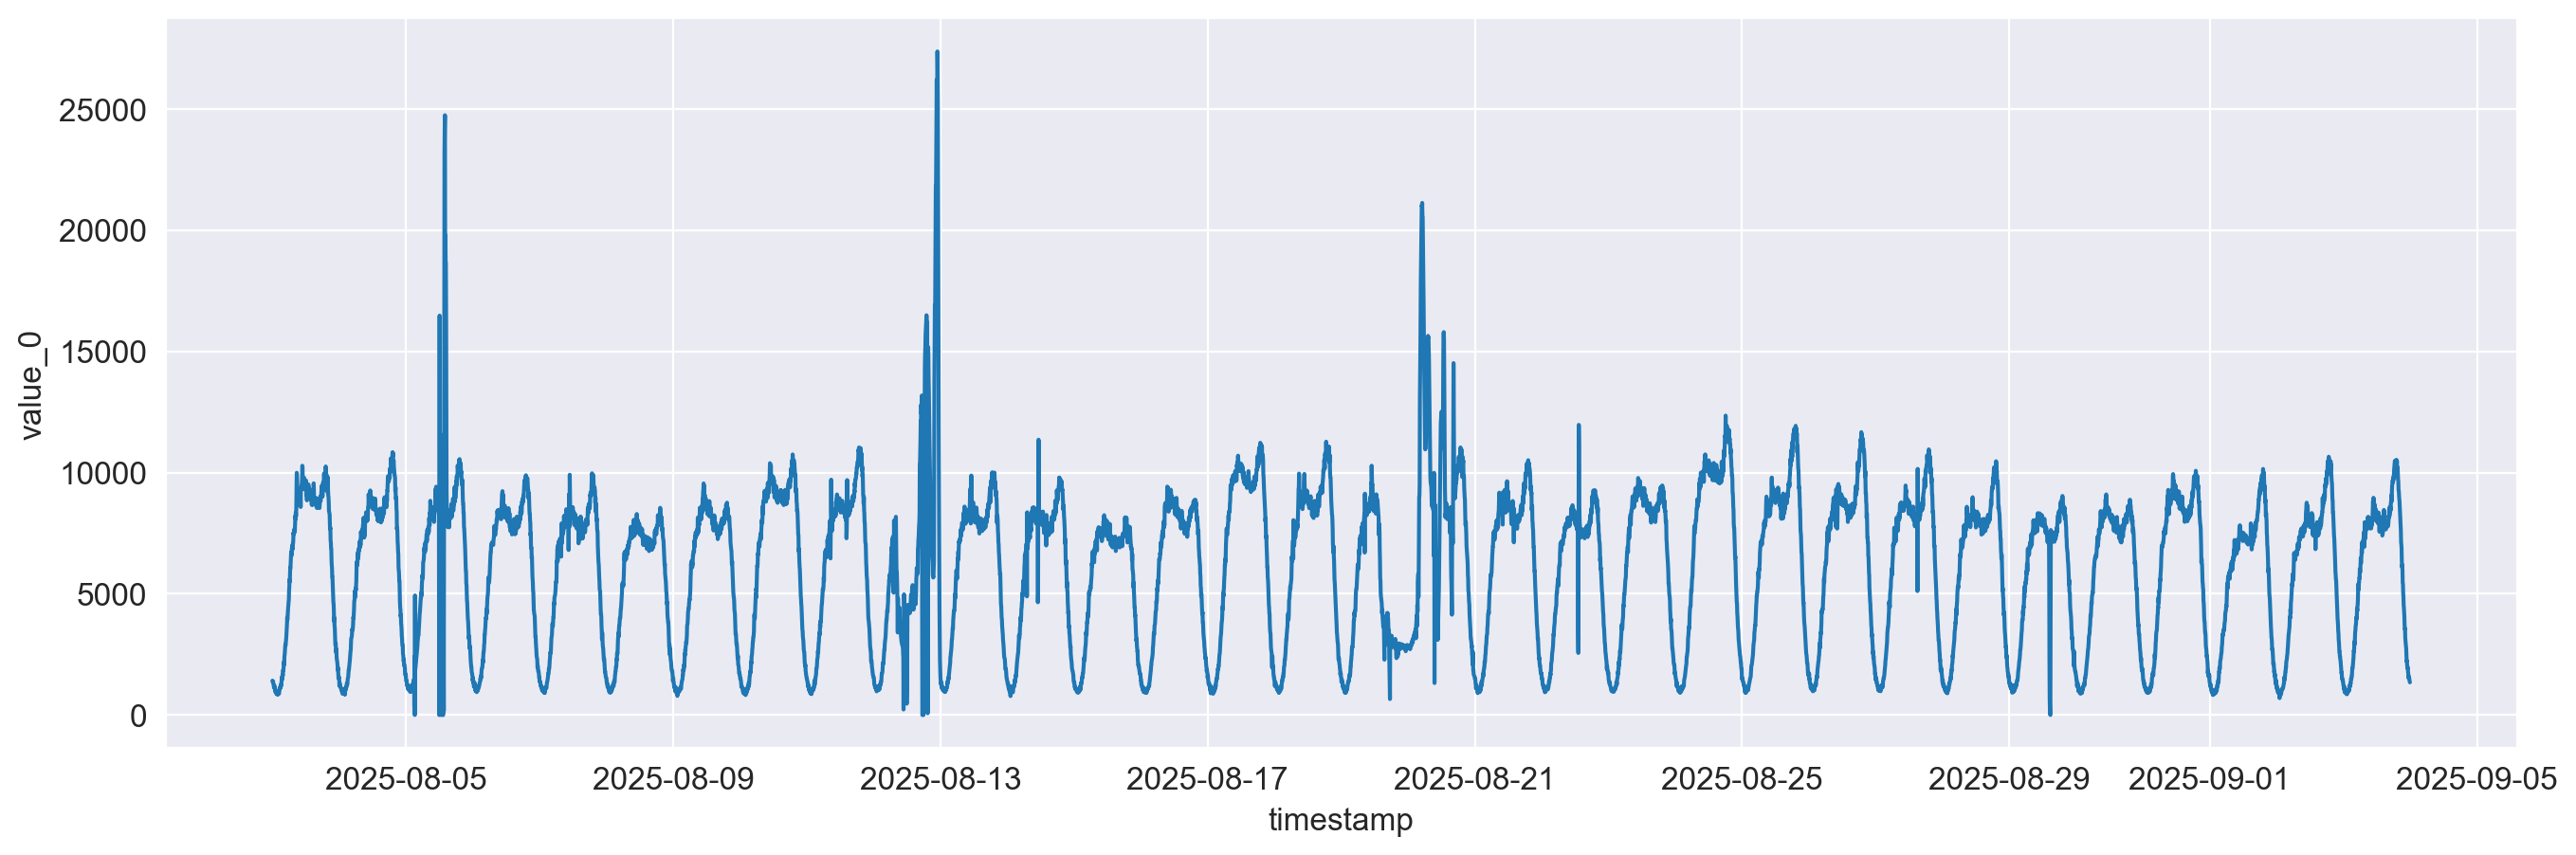

In [ ]:
import pandas as pd

time_series = pd.read_csv('time_series_examples/market_apps_search_request_screen.csv')
time_series['timestamp'] = pd.to_datetime(time_series['timestamp'], unit='ms')
time_series = time_series.set_index(time_series['timestamp'], drop=True)
time_series = time_series.drop(columns=['timestamp'])

sns.lineplot(x=time_series.index, y=time_series['value_0'])
time_series.head()

In [3]:
from anomaly_detection import DEFAULT_CONFIGURATION, AnomalyDetectionSystem

system = AnomalyDetectionSystem(**DEFAULT_CONFIGURATION)
detection_result = system.detect(time_series=time_series)
# или можно так
# detection_result = system.detect(time_series=(time_series.index.to_list(), time_series['value_0'].to_list()))

<Axes: title={'center': 'Time Series'}, xlabel='Time', ylabel='Value'>

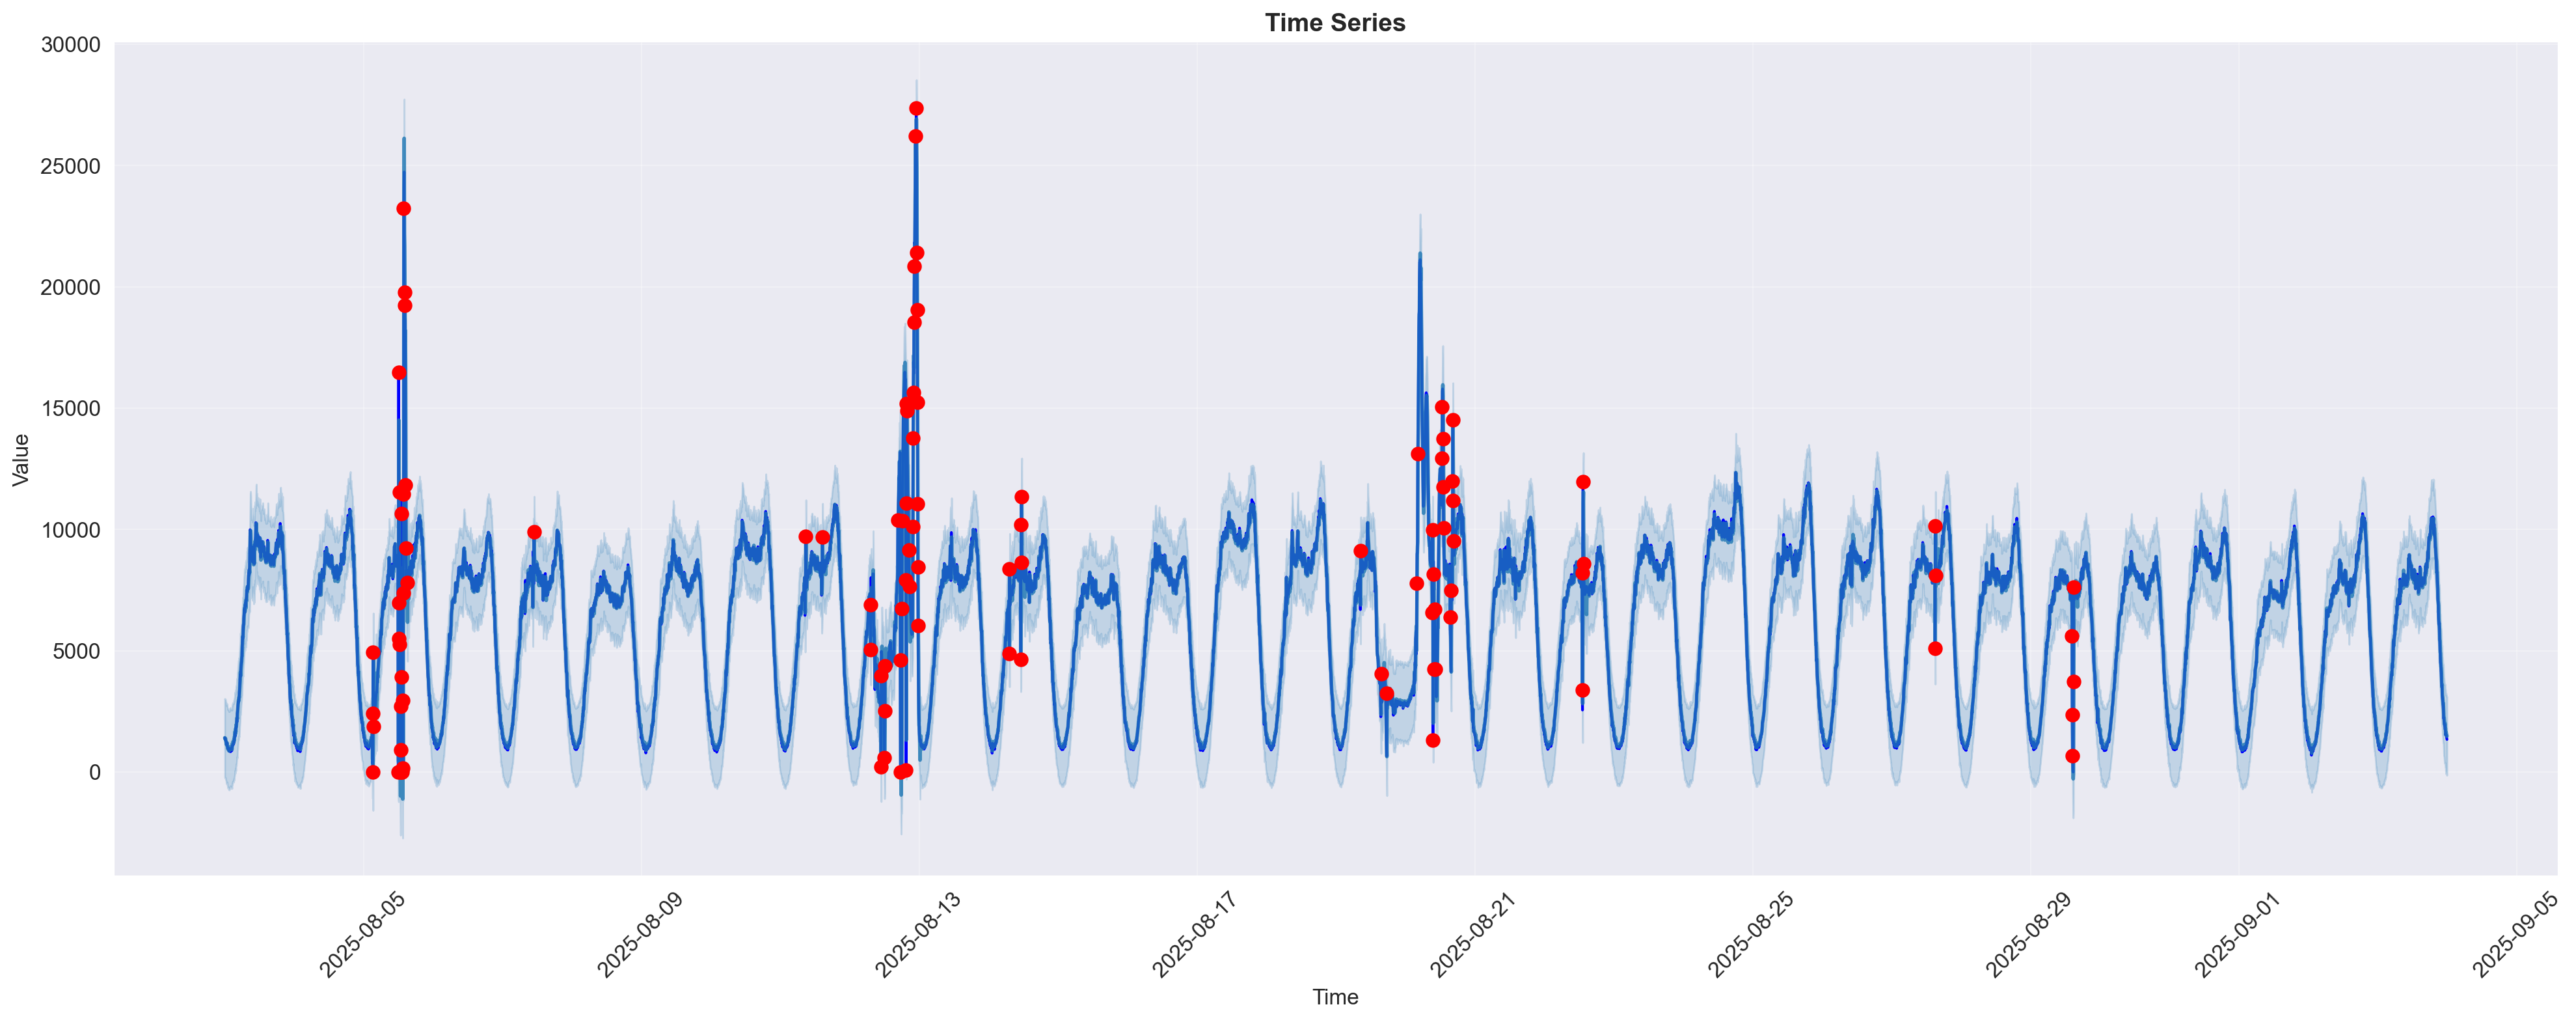

In [6]:
import plots_matplotlib

fig = plots_matplotlib.plot_time_series(time_series)
plots_matplotlib.add_anomalies(
    fig,
    time_series,
    detection_result.is_anomaly,
    detection_result.expected_value,
    detection_result.expected_bounds,
)

In [7]:
import plots_plotly

fig = plots_plotly.plot_time_series(time_series)
plots_plotly.add_anomalies(
    fig,
    time_series,
    detection_result.is_anomaly,
    detection_result.expected_value,
    detection_result.expected_bounds,
)